# 11. Improved Similarity Analysis

Bu bölümde her gerçek görüntü, oluşturulan tüm görüntüler ile karşılaştırılmaktadır.

Sabit indeks eşleştirmesi yerine her gerçek görüntü için en yüksek benzerlik değeri hesaplanmaktadır.

Bu yöntem literatürde Nearest Neighbor Similarity olarak kullanılmaktadır.

In [8]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
real = np.load("../embeddings/chrd_real_embeddings.npy")

tr = np.load("../embeddings/sdxl_tr_embeddings.npy")

en = np.load("../embeddings/sdxl_en_embeddings.npy")

print(real.shape)
print(tr.shape)
print(en.shape)

(82, 768)
(96, 768)
(96, 768)


## Gerçek Görseller ile Türkçe Üretilen Görseller

Her gerçek görüntü için en yüksek benzerlik değeri hesaplanacaktır.

In [10]:
similarity_real_tr = cosine_similarity(real, tr)

nearest_tr = similarity_real_tr.max(axis=1)

nearest_tr.shape

(82,)

## Gerçek Görseller ile İngilizce Üretilen Görseller

In [11]:
similarity_real_en = cosine_similarity(real, en)

nearest_en = similarity_real_en.max(axis=1)

nearest_en.shape

(82,)

## Türkçe ve İngilizce Görseller Arası Benzerlik

In [12]:
similarity_tr_en = cosine_similarity(tr, en)

nearest_tr_en = similarity_tr_en.max(axis=1)


nearest_tr_en.shape

(96,)

## Ortalama En Yakın Benzerlik Sonuçları

In [13]:
print("Nearest Real → TR :", np.mean(nearest_tr))

print("Nearest Real → EN :", np.mean(nearest_en))

print("Nearest TR → EN :", np.mean(nearest_tr_en))

Nearest Real → TR : 0.6112279
Nearest Real → EN : 0.5781631
Nearest TR → EN : 0.7509119


## Benzerlik Dağılımının Görselleştirilmesi

In [14]:
import matplotlib.pyplot as plt

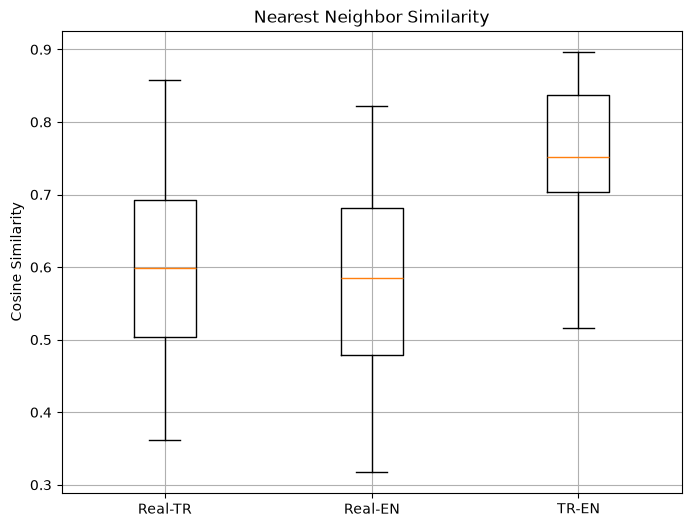

In [15]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [nearest_tr, nearest_en, nearest_tr_en],
    tick_labels=[
        "Real-TR",
        "Real-EN",
        "TR-EN"
    ]
)

plt.ylabel("Cosine Similarity")

plt.title("Nearest Neighbor Similarity")

plt.grid(True)

plt.show()

## Sonuçların Kaydedilmesi

In [16]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Nearest Real-TR",
        "Nearest Real-EN",
        "Nearest TR-EN"
    ],

    "Similarity":[

        nearest_tr.mean(),

        nearest_en.mean(),

        nearest_tr_en.mean()
    ]
})

results

,Metric,Similarity
0,Nearest Real-TR,0.611228
1,Nearest Real-EN,0.578163
2,Nearest TR-EN,0.750912


In [17]:
results.to_csv(

    "../results/improved_similarity.csv",

    index=False
)

print("Kaydedildi.")

Kaydedildi.
